### TerraNova Disaster Cost Recovery Modelling & Evaluation

In [2]:
# Purpose:

# The purpose of this modelling stage is to train machine learning models
# that can predict expected disaster recovery cost.
#
# Disaster recovery costs are usually highly skewed.
# This means a small number of disasters may have extremely high costs,
# while many others may have low or zero cost.
#
# To reduce the effect of extreme values, we use a log-transformed target:

# log_totalobligated
#
# Models Used:
#
# 1. Linear Regression
#    - Simple, fast, interpretable baseline model.
#
# 2. Random Forest Regressor
#    - Handles non-linear relationships and feature interactions.
#
# 3. XGBoost Regressor
#    - Advanced boosting model, often strong for structured tabular data.

### STEP 1 - Import Libraries

In [1]:

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")

os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(
    os.path.join(DATA_PROCESSED, "features_fema.csv")
)

print(df.shape)
df.head()

(5184, 22)


,disasternumber,state,declarationtype,incidenttype,fydeclared,designatedarea,declarationrequestnumber,disaster_duration_days,declaration_delay_days,declaration_year,...,declaration_season,fy_declaration_count,state_declaration_count,incident_frequency,state_incident_count,state_year_count,avg_duration_days,avg_delay_days,totalobligated,log_totalobligated
0,3610,PR,EM,Severe Storm,2024,Adjuntas (Municipio),24124,3.0,0,2024,...,Summer,2147,2116,19308,380,91,3.0,0.0,0.00,0.000000
1,5529,OR,FM,Fire,2024,Washington (County),24122,0.0,1,2024,...,Summer,2147,646,3876,180,33,0.0,1.0,0.00,0.000000
2,5528,OR,FM,Fire,2024,Jefferson (County),24116,0.0,2,2024,...,Summer,2147,646,3876,180,33,0.0,2.0,0.00,0.000000
3,5527,OR,FM,Fire,2024,Deschutes (County),24111,0.0,0,2024,...,Summer,2147,646,3876,180,33,0.0,0.0,0.00,0.000000
4,4312,CA,DR,Severe Storm,2017,Resighini Rancheria (Indian Reservation),17035,3.0,83,2017,...,Spring,1835,1689,19308,384,115,3.0,83.0,269934.77,12.505939


### STEP 2 - Prepare Target

In [2]:
# Original target:
# totalobligated
#
# Modelling target:
# log_totalobligated
#
# We use the log-transformed version because recovery cost is highly skewed.

target = "log_totalobligated"

print("Target column:", target)
print(df[target].describe())

Target column: log_totalobligated
count    5184.000000
mean        5.508417
std         7.744469
min         0.000000
25%         0.000000
50%         0.000000
75%        15.102262
max        24.311476
Name: log_totalobligated, dtype: float64


### STEP 3 - Features and Train/Test Split



In [4]:
# step 3a: feature selection

FEATURE_COLS = [
    "fydeclared",
    "declaration_delay_days",
    "avg_delay_days",
    "declaration_year",
    "declaration_month",
    "declaration_quarter",
    "declaration_season",
    "state",
    "declarationtype",
    "incidenttype",
    "designatedarea"
]

print(f"{len(FEATURE_COLS)} features selected")
print(FEATURE_COLS)

11 features selected
['fydeclared', 'declaration_delay_days', 'avg_delay_days', 'declaration_year', 'declaration_month', 'declaration_quarter', 'declaration_season', 'state', 'declarationtype', 'incidenttype', 'designatedarea']


In [5]:
# step 3b:   Prepare X and y

X = df[FEATURE_COLS]
y = df["log_totalobligated"]

print(X.shape)
print(y.shape)

(5184, 11)
(5184,)


In [6]:
# step 3c split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {len(X_train):,}")
print(f"Test : {len(X_test):,}")

Train: 4,147
Test : 1,037



### STEP 4 - Encoding and Scaling Pipeline

In [7]:
# step 4a: Identify Numeric and Categorical Features

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 6
['fydeclared', 'declaration_delay_days', 'avg_delay_days', 'declaration_year', 'declaration_month', 'declaration_quarter']

Categorical features: 5
['declaration_season', 'state', 'declarationtype', 'incidenttype', 'designatedarea']


In [9]:
# step 4b: Create Preprocessing Pipeline

# Numeric columns:
# - Fill missing values using median
# - Scale values for Linear Regression

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical columns:
# - Fill missing values using most frequent category
# - One-hot encode categories
# - Ignore unseen categories during prediction

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

### STEP 5 - Define Models



In [10]:
# step 5a: Define Models

lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

###  STEP 6 - Training Process

In [11]:
# step 6a: Train and Evaluate Models

MODELS = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = {}
trained_models = {}

for name, model in MODELS.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    preds_log = pipeline.predict(X_test)

    mae_log = mean_absolute_error(y_test, preds_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, preds_log))
    r2 = r2_score(y_test, preds_log)

    y_test_original = np.expm1(y_test)
    preds_original = np.expm1(preds_log)

    mae_original = mean_absolute_error(y_test_original, preds_original)
    rmse_original = np.sqrt(mean_squared_error(y_test_original, preds_original))

    results[name] = {
        "MAE_log": mae_log,
        "RMSE_log": rmse_log,
        "R2": r2,
        "MAE_original": mae_original,
        "RMSE_original": rmse_original
    }

    trained_models[name] = pipeline

    print(
        f"{name:25s} | "
        f"RMSE log: {rmse_log:.4f} | "
        f"R2: {r2:.4f} | "
        f"MAE original: {mae_original:,.2f}"
    )

Linear Regression         | RMSE log: 5.3626 | R2: 0.5063 | MAE original: 16,264,410,033.04
Random Forest             | RMSE log: 3.0674 | R2: 0.8385 | MAE original: 61,430,972.54
XGBoost                   | RMSE log: 3.0153 | R2: 0.8439 | MAE original: 69,907,562.33


In [12]:
# step 6b: Compare Model Performance

# MAE:
# Average prediction error.
#
# RMSE:
# Penalises large errors more strongly.
#
# R2:
# Shows how much variation in disaster recovery cost the model explains.
#
# A good model should have:
# - Lower MAE
# - Lower RMSE
# - Higher R2

results_df = (
    pd.DataFrame(results)
    .T
    .sort_values("RMSE_log")
)

results_df

,MAE_log,RMSE_log,R2,MAE_original,RMSE_original
XGBoost,1.289780,3.015306,0.843905,6.990756e+07,8.978934e+08
Random Forest,1.181454,3.067403,0.838464,6.143097e+07,8.426281e+08
Linear Regression,4.026711,5.362564,0.506290,1.626441e+10,5.185377e+11


In [13]:
# step 6c: Select Best Model

best_name = results_df.index[0]
best_model = trained_models[best_name]

print(f"Best model: {best_name}")

Best model: XGBoost


### STEP 7 - feature importance

In [14]:
# step 7a: Feature Importance

# Feature importance is only available for tree-based models.
# Here we use Random Forest because it gives easy-to-read feature importance.

rf_pipeline = trained_models["Random Forest"]

importances = rf_pipeline.named_steps["model"].feature_importances_
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

fi = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

fi.head(20)

,feature,importance
3,num__declaration_year,0.282221
1,num__declaration_delay_days,0.234339
2,num__avg_delay_days,0.195214
69,cat__declarationtype_DR,0.117138
0,num__fydeclared,0.047869
83,cat__incidenttype_Hurricane,0.018855
70,cat__declarationtype_EM,0.015386
71,cat__declarationtype_FM,0.012321
72,cat__incidenttype_Biological,0.004123
87,cat__incidenttype_Severe Storm,0.003099


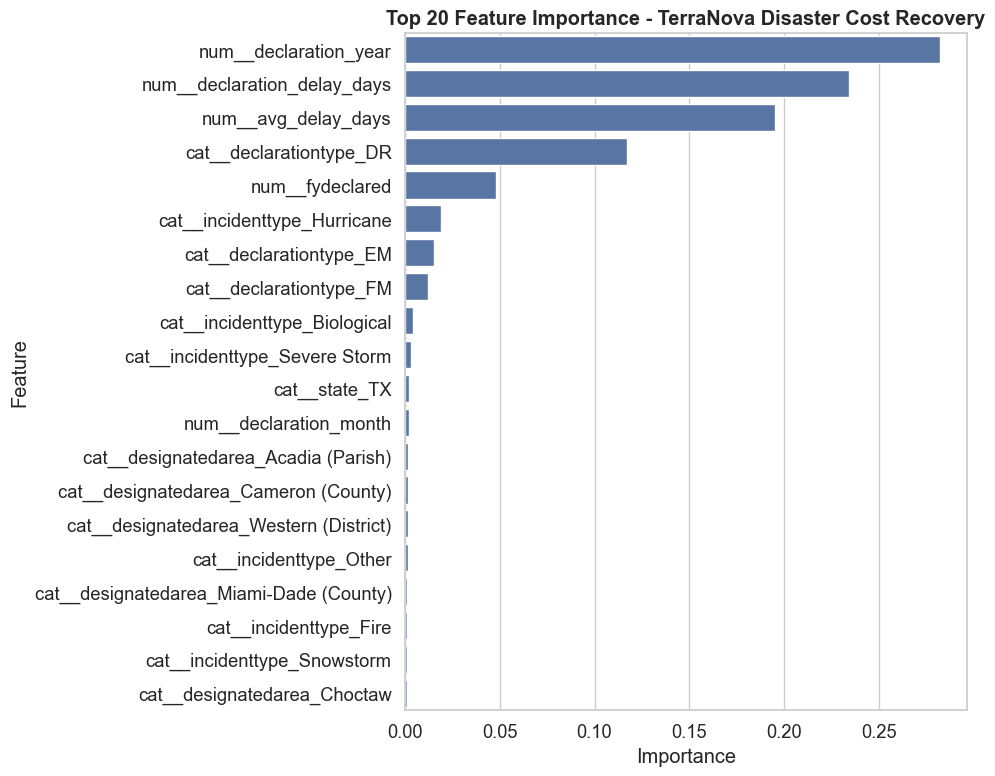

In [15]:
# step 7b: - Plot Top 20 Important Features

top_20_features = fi.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_20_features,
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importance - TerraNova Disaster Cost Recovery", fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

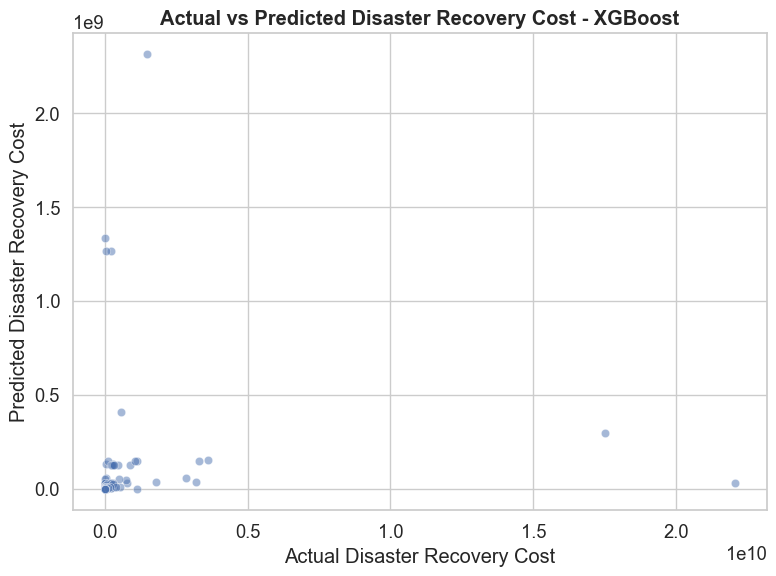

In [17]:
# step 7c: Predicted vs Actual Plot

preds_log = best_model.predict(X_test)

actual = np.expm1(y_test)
predicted = np.expm1(preds_log)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=actual,
    y=predicted,
    alpha=0.5
)

plt.xlabel("Actual Disaster Recovery Cost")
plt.ylabel("Predicted Disaster Recovery Cost")
plt.title(f"Actual vs Predicted Disaster Recovery Cost - {best_name}", fontweight="bold")

plt.tight_layout()
plt.show()

### STEP 9 - Save Best Model

In [18]:
# step 9a: Save Best Model

model_path = os.path.join(MODEL_DIR, "terranova_disaster_cost_model.pkl")

joblib.dump(best_model, model_path)

print(f"Best model saved: {best_name}")
print("Saved to:", model_path)

Best model saved: XGBoost
Saved to: ..\models\terranova_disaster_cost_model.pkl
